# 범주화 기반 고객 군집화

수치형 변수의 이상치 영향을 줄이기 위해 원본 수치값을 범위형 변수로 변환한 뒤 KMeans 군집화를 진행한다. `churned`는 군집 생성에는 사용하지 않고, 군집이 만들어진 뒤 해석용으로만 사용한다.

In [1]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder

font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
font_name = next((font for font in font_candidates if font in available_fonts), 'DejaVu Sans')

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='Set2', font=font_name)

RANDOM_STATE = 42
print(f'사용 폰트: {font_name}')

사용 폰트: AppleGothic


In [2]:
data_candidates = [
    Path('data/user_behavior_50000/netflix_user_behavior_churn_50000.csv'),
    Path('../data/user_behavior_50000/netflix_user_behavior_churn_50000.csv'),
]
data_path = next(path for path in data_candidates if path.exists())

df = pd.read_csv(data_path)
df.shape, df.head()

((50000, 20),
   user_id  age  gender         region subscription_type payment_method  \
 0  N00001   33    Male         Europe             Basic    Credit Card   
 1  N00002   41    Male         Africa           Premium    Credit Card   
 2  N00003   28  Female         Europe          Standard      Gift Card   
 3  N00004   40  Female  North America             Basic    Credit Card   
 4  N00005   54    Male         Europe          Standard         Paypal   
 
   primary_device  account_age_months favorite_genre time_of_day  \
 0       Smart TV                  38         Comedy   Afternoon   
 1         Tablet                  49         Comedy     Evening   
 2         Laptop                  20          Drama     Evening   
 3         Mobile                  19         Action     Evening   
 4         Mobile                  51        Romance     Evening   
 
   recommendation_source  session_count  avg_watch_time_minutes_per_week  \
 0              Trending              1         

## 군집화 피처 설계

- 제외: `user_id`, `churned`, `region`, `gender`
- 원칙: 이상치 영향을 받을 수 있는 수치형 변수는 범위형/범주형으로 변환
- 유지: 요금제, 결제수단, 기기, 선호 장르, 이용 시간대, 추천 경로
- 해석: 군집 생성 후 `churned`를 붙여 군집별 이탈률을 확인

In [3]:
cluster_source = df.copy()

cluster_source['age_group'] = pd.cut(
    cluster_source['age'],
    bins=[-1, 19, 29, 39, 49, 59, float('inf')],
    labels=['0~19세', '20대', '30대', '40대', '50대', '60세 이상'],
)

cluster_source['account_age_segment'] = pd.cut(
    cluster_source['account_age_months'],
    bins=[-1, 6, 24, 60, float('inf')],
    labels=['신규', '성장', '장기', '충성'],
)

cluster_source['session_count_segment'] = pd.cut(
    cluster_source['session_count'],
    bins=[0, 1, 2, 3, float('inf')],
    labels=['1회', '2회', '3회', '4회 이상'],
    include_lowest=True,
)

cluster_source['watch_time_segment'] = pd.qcut(
    cluster_source['avg_watch_time_minutes_per_week'],
    q=4,
    labels=['시청시간 낮음', '시청시간 중하', '시청시간 중상', '시청시간 높음'],
    duplicates='drop',
)

cluster_source['watch_sessions_segment'] = pd.qcut(
    cluster_source['watch_sessions_per_week'],
    q=4,
    labels=['시청빈도 낮음', '시청빈도 중하', '시청빈도 중상', '시청빈도 높음'],
    duplicates='drop',
)

cluster_source['completion_segment'] = pd.cut(
    cluster_source['completion_rate'],
    bins=[-1, 50, 70, 85, 100],
    labels=['완료율 낮음', '완료율 보통', '완료율 높음', '완료율 매우 높음'],
)

cluster_source['avg_rating_segment'] = pd.cut(
    cluster_source['avg_rating_given'],
    bins=[0, 3, 4, 5],
    labels=['평점 낮음', '평점 보통', '평점 높음'],
    include_lowest=True,
)

cluster_source['app_rating_segment'] = pd.cut(
    cluster_source['app_rating'],
    bins=[0, 3, 4, 5],
    labels=['앱평점 낮음', '앱평점 보통', '앱평점 높음'],
    include_lowest=True,
)

cluster_source['recommendation_click_segment'] = pd.cut(
    cluster_source['recommendation_click_rate'],
    bins=[-1, 20, 40, 60, 100],
    labels=['추천반응 낮음', '추천반응 중하', '추천반응 중상', '추천반응 높음'],
)

cluster_source['login_recency_segment'] = pd.cut(
    cluster_source['days_since_last_login'],
    bins=[-1, 3, 14, 30, float('inf')],
    labels=['0-3일', '4-14일', '15-30일', '31일 이상'],
)

cluster_source.filter(like='_segment').head()

,account_age_segment,session_count_segment,watch_time_segment,watch_sessions_segment,completion_segment,avg_rating_segment,app_rating_segment,recommendation_click_segment,login_recency_segment
0,장기,1회,시청시간 중상,시청빈도 중하,완료율 높음,평점 보통,앱평점 보통,추천반응 중상,0-3일
1,장기,1회,시청시간 낮음,시청빈도 중하,완료율 보통,평점 보통,앱평점 보통,추천반응 중하,15-30일
2,성장,1회,시청시간 중상,시청빈도 중하,완료율 높음,평점 보통,앱평점 낮음,추천반응 중하,4-14일
3,성장,1회,시청시간 낮음,시청빈도 중상,완료율 높음,평점 보통,앱평점 보통,추천반응 중하,31일 이상
4,장기,3회,시청시간 낮음,시청빈도 낮음,완료율 보통,평점 높음,앱평점 보통,추천반응 중상,4-14일


In [4]:
cluster_feature_cols = [
    'age_group',
    'account_age_segment',
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre',
    'time_of_day',
    'recommendation_source',
    'session_count_segment',
    'watch_time_segment',
    'watch_sessions_segment',
    'completion_segment',
    'avg_rating_segment',
    'app_rating_segment',
    'recommendation_click_segment',
    'login_recency_segment',
]

cluster_df = cluster_source[cluster_feature_cols].copy()
cluster_df = cluster_df.astype('object').fillna('Unknown')

cluster_df.shape, cluster_df.head()

((50000, 16),
   age_group account_age_segment subscription_type payment_method  \
 0       30대                  장기             Basic    Credit Card   
 1       40대                  장기           Premium    Credit Card   
 2       20대                  성장          Standard      Gift Card   
 3       40대                  성장             Basic    Credit Card   
 4       50대                  장기          Standard         Paypal   
 
   primary_device favorite_genre time_of_day recommendation_source  \
 0       Smart TV         Comedy   Afternoon              Trending   
 1         Tablet         Comedy     Evening                Search   
 2         Laptop          Drama     Evening                   Ads   
 3         Mobile         Action     Evening             Algorithm   
 4         Mobile        Romance     Evening                Friend   
 
   session_count_segment watch_time_segment watch_sessions_segment  \
 0                    1회            시청시간 중상                시청빈도 중하   
 1      

In [5]:
category_summary = pd.DataFrame({
    'unique': cluster_df.nunique(),
    'missing': cluster_df.isna().sum(),
})

category_summary

,unique,missing
age_group,6,0
account_age_segment,4,0
subscription_type,3,0
payment_method,4,0
primary_device,4,0
favorite_genre,7,0
time_of_day,4,0
recommendation_source,5,0
session_count_segment,4,0
watch_time_segment,4,0


## One-Hot Encoding

모든 군집화 입력 변수가 범주형이므로 One-Hot Encoding 후 KMeans를 적용한다.

In [6]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_cluster = encoder.fit_transform(cluster_df)

X_cluster.shape

(50000, 67)

## 군집 수 선택

`k=2~8` 범위를 확인한다. Silhouette score는 계산 비용을 줄이기 위해 표본 10,000개 기준으로 계산한다.

In [7]:
k_values = range(2, 9)
k_rows = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = model.fit_predict(X_cluster)
    score = silhouette_score(
        X_cluster,
        labels,
        sample_size=min(10000, X_cluster.shape[0]),
        random_state=RANDOM_STATE,
    )
    k_rows.append({'k': k, 'inertia': model.inertia_, 'silhouette': score})

k_result = pd.DataFrame(k_rows)
k_result

,k,inertia,silhouette
0,2,511920.415176,0.050539
1,3,495667.862806,0.047556
2,4,483406.464540,0.044124
3,5,476417.092782,0.040955
4,6,471895.260556,0.034284
5,7,466155.759578,0.033879
6,8,462121.557909,0.033710


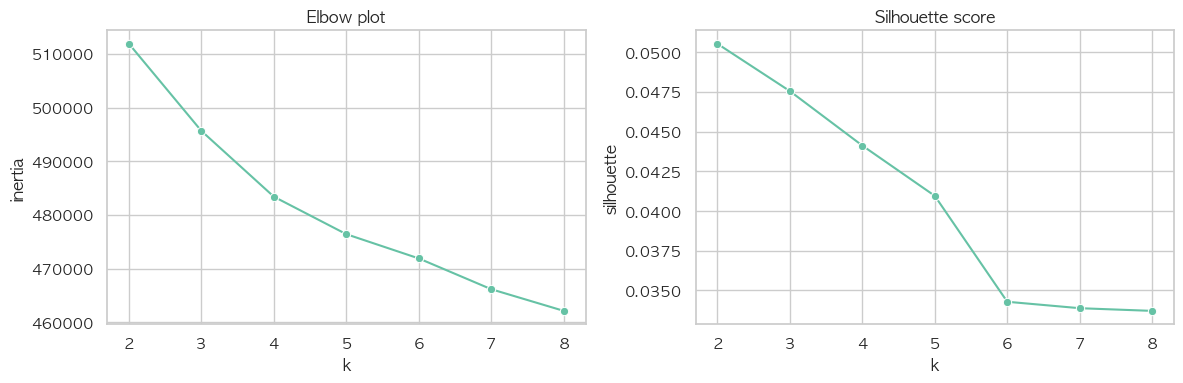

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=k_result, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow plot')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')

sns.lineplot(data=k_result, x='k', y='silhouette', marker='o', ax=axes[1])
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette')

plt.tight_layout()
plt.show()

**실제 해석**

- `k=2~8` 모두 silhouette score가 0.03~0.05 수준으로 낮다. 즉 군집 간 경계가 매우 선명한 데이터는 아니다.
- silhouette만 보면 `k=2`가 가장 높지만, 비즈니스 세그먼트로는 너무 단순하다.
- `k=4`는 고위험군, Basic 중심 중위험군, 일반 유지군, 핵심 충성군으로 해석 가능한 구조를 만들어준다.
- 따라서 이 노트북에서는 해석 가능성과 세그먼트 활용성을 기준으로 기본 `SELECTED_K = 4`를 사용한다.

## 최종 군집 생성

`SELECTED_K`는 위 그래프를 보고 수정한다. 기본값은 4로 둔다.

In [9]:
SELECTED_K = 4

kmeans = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init='auto')
cluster_labels = kmeans.fit_predict(X_cluster)

analysis_df = cluster_source.copy()
analysis_df['cluster'] = cluster_labels

analysis_df['cluster'].value_counts().sort_index()

cluster
0    11199
1    11112
2    16496
3    11193
Name: count, dtype: int64

## 차원축소 시각화

One-Hot Encoding 결과는 67차원 sparse matrix이므로, TruncatedSVD로 2차원에 투영해 군집이 시각적으로 어떻게 배치되는지 확인한다. 이 시각화는 군집 생성용이 아니라 결과 검증과 설명을 위한 용도다.

In [10]:
svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
svd_coords = svd.fit_transform(X_cluster)

svd_df = pd.DataFrame({
    'svd_1': svd_coords[:, 0],
    'svd_2': svd_coords[:, 1],
    'cluster': analysis_df['cluster'].astype(str),
    'churned': analysis_df['churned'].map({0: '유지', 1: '이탈'}),
})

pd.DataFrame({
    'component': ['svd_1', 'svd_2'],
    'explained_variance_ratio': svd.explained_variance_ratio_,
    'cumulative_explained_variance_ratio': svd.explained_variance_ratio_.cumsum(),
})

,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,svd_1,0.006382,0.006382
1,svd_2,0.074309,0.080690


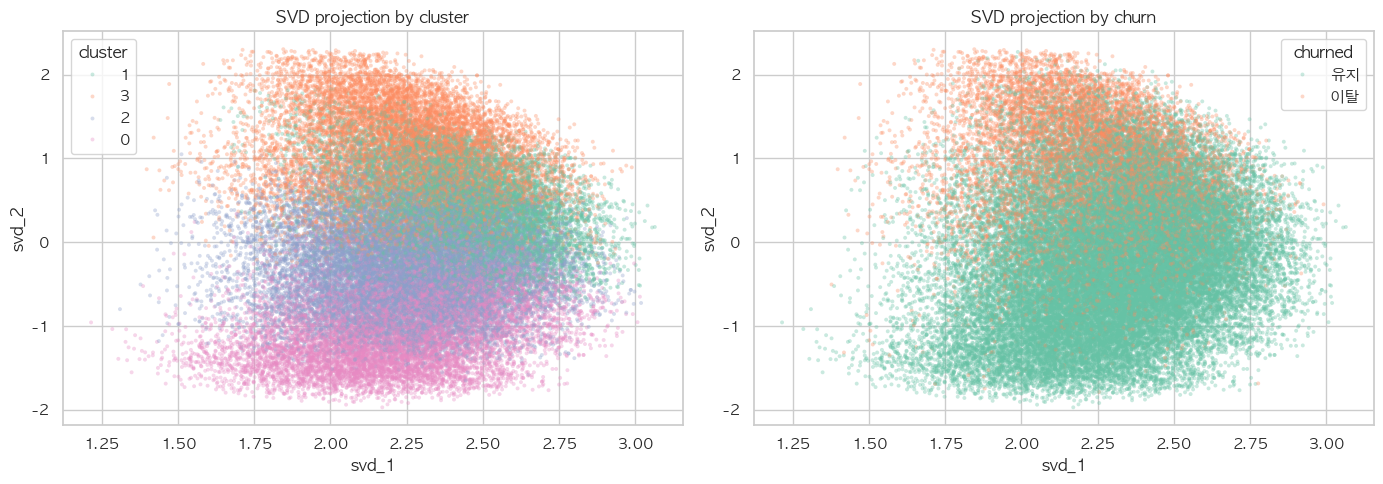

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=svd_df,
    x='svd_1',
    y='svd_2',
    hue='cluster',
    s=8,
    alpha=0.35,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title('SVD projection by cluster')

sns.scatterplot(
    data=svd_df,
    x='svd_1',
    y='svd_2',
    hue='churned',
    s=8,
    alpha=0.35,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title('SVD projection by churn')

plt.tight_layout()
plt.show()

**실제 해석**

- 2차원 SVD의 누적 설명분산은 약 8.1% 수준이다. One-Hot Encoding된 범주형 데이터의 정보가 여러 축에 분산되어 있어, 2차원 그림만으로 군집 품질을 판단하기에는 부족하다.
- 따라서 SVD scatter plot은 군집이 완전히 분리되는지 확인하는 참고용으로만 사용하고, 최종 해석은 `cluster_summary`와 `cluster_profile`을 중심으로 보는 것이 적절하다.
- 만약 2D 시각화에서 군집이 많이 겹쳐 보이더라도, 범주형 조합 기반 군집화에서는 자연스러운 현상일 수 있다. 이 경우 군집별 이탈률과 대표 카테고리가 비즈니스적으로 구분되는지가 더 중요하다.

## 군집별 이탈률과 프로파일

In [12]:
overall_churn_rate = analysis_df['churned'].mean()

cluster_summary = (
    analysis_df.groupby('cluster')
    .agg(
        users=('user_id', 'count'),
        churners=('churned', 'sum'),
        churn_rate=('churned', 'mean'),
        avg_age=('age', 'mean'),
        avg_account_age_months=('account_age_months', 'mean'),
        avg_days_since_last_login=('days_since_last_login', 'mean'),
        avg_watch_time=('avg_watch_time_minutes_per_week', 'mean'),
        avg_completion_rate=('completion_rate', 'mean'),
        avg_recommendation_click_rate=('recommendation_click_rate', 'mean'),
    )
    .assign(
        user_share=lambda x: x['users'] / len(analysis_df),
        churner_share=lambda x: x['churners'] / analysis_df['churned'].sum(),
        lift=lambda x: x['churn_rate'] / overall_churn_rate,
    )
    .sort_values('churn_rate', ascending=False)
)

cluster_summary

,users,churners,churn_rate,avg_age,avg_account_age_months,avg_days_since_last_login,avg_watch_time,avg_completion_rate,avg_recommendation_click_rate,user_share,churner_share,lift
cluster,,,,,,,,,,,,
3,11193,5365,0.479317,39.145627,40.456982,20.915662,125.403288,65.411954,29.885107,0.22386,0.510952,2.282464
1,11112,2951,0.265569,39.110691,40.794186,12.446454,252.625990,72.019798,37.250810,0.22224,0.281048,1.264613
2,16496,1871,0.113421,39.173254,46.980723,9.985209,242.836809,73.478419,39.810984,0.32992,0.178190,0.540102
0,11199,313,0.027949,39.453344,49.918118,6.959461,507.266452,81.420038,47.046790,0.22398,0.029810,0.133090


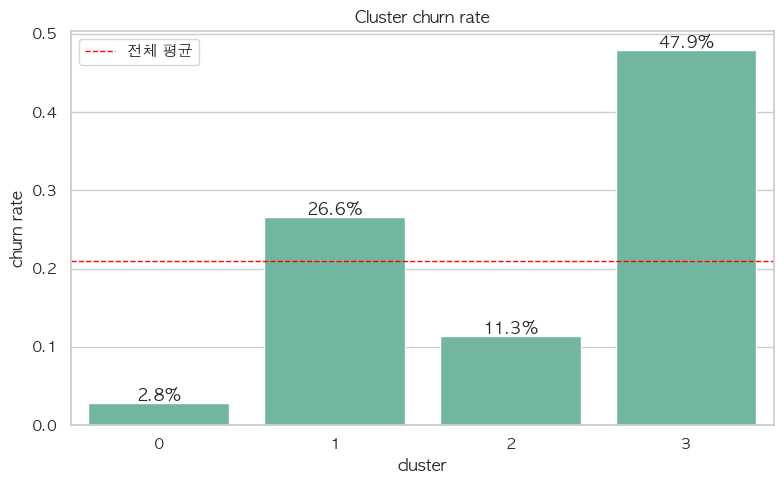

In [13]:
plot_summary = cluster_summary.reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_summary, x='cluster', y='churn_rate', ax=ax)
ax.axhline(overall_churn_rate, color='red', linestyle='--', linewidth=1, label='전체 평균')
ax.set_title('Cluster churn rate')
ax.set_xlabel('cluster')
ax.set_ylabel('churn rate')
ax.legend()

for container in ax.containers:
    ax.bar_label(container, labels=[f'{v.get_height():.1%}' for v in container])

plt.tight_layout()
plt.show()

In [14]:
def top_category_profile(data, cluster_col, cols):
    rows = []
    for cluster, group in data.groupby(cluster_col):
        row = {'cluster': cluster}
        for col in cols:
            share = group[col].value_counts(normalize=True, dropna=False)
            row[f'{col}_top'] = share.index[0]
            row[f'{col}_top_share'] = share.iloc[0]
        rows.append(row)
    return pd.DataFrame(rows).sort_values('cluster')

profile_cols = [
    'subscription_type',
    'payment_method',
    'primary_device',
    'favorite_genre',
    'time_of_day',
    'recommendation_source',
    'age_group',
    'account_age_segment',
    'login_recency_segment',
    'watch_time_segment',
    'completion_segment',
]

cluster_profile = top_category_profile(analysis_df, 'cluster', profile_cols)
cluster_profile

,cluster,subscription_type_top,subscription_type_top_share,payment_method_top,payment_method_top_share,primary_device_top,primary_device_top_share,favorite_genre_top,favorite_genre_top_share,time_of_day_top,...,age_group_top,age_group_top_share,account_age_segment_top,account_age_segment_top_share,login_recency_segment_top,login_recency_segment_top_share,watch_time_segment_top,watch_time_segment_top_share,completion_segment_top,completion_segment_top_share
0,0,Premium,0.442182,Credit Card,0.435932,Smart TV,0.655326,Comedy,0.208590,Evening,...,30대,0.375480,장기,0.552996,0-3일,0.603268,시청시간 높음,0.977409,완료율 높음,0.487097
1,1,Basic,0.999820,Credit Card,0.428276,Smart TV,0.522588,Comedy,0.205634,Evening,...,30대,0.372570,장기,0.589993,0-3일,0.480472,시청시간 중하,0.432235,완료율 높음,0.526548
2,2,Standard,0.611178,Credit Card,0.434893,Smart TV,0.443562,Comedy,0.200109,Evening,...,30대,0.374818,장기,0.577231,0-3일,0.533705,시청시간 중상,0.480238,완료율 높음,0.564016
3,3,Basic,0.532029,Credit Card,0.418565,Mobile,0.407397,Comedy,0.185652,Evening,...,30대,0.371661,장기,0.572233,31일 이상,0.331993,시청시간 낮음,0.916555,완료율 보통,0.645403


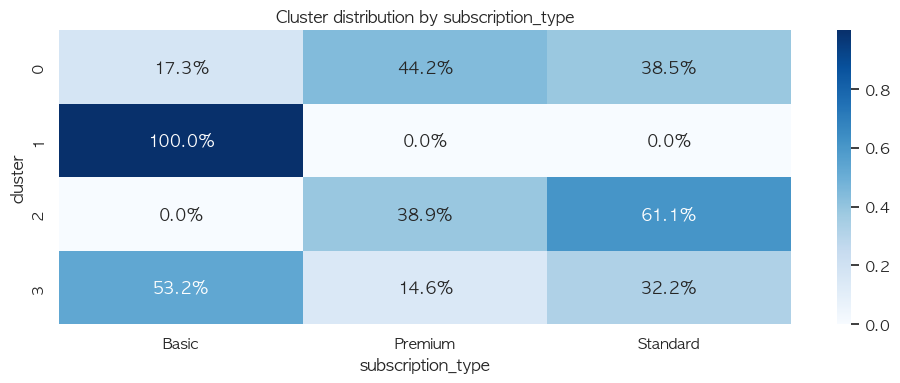

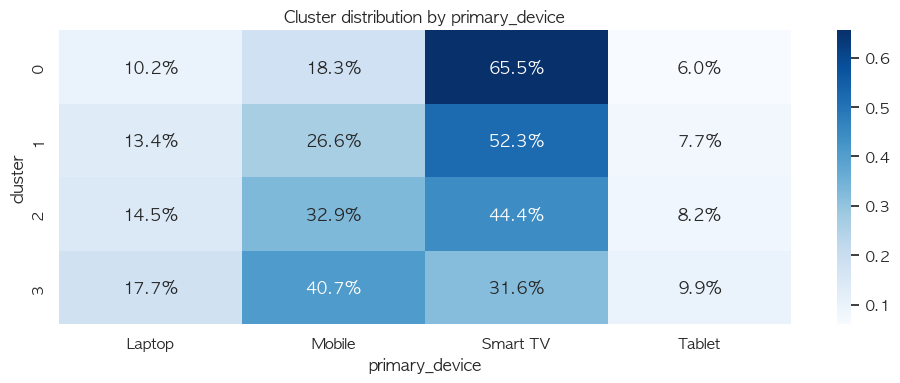

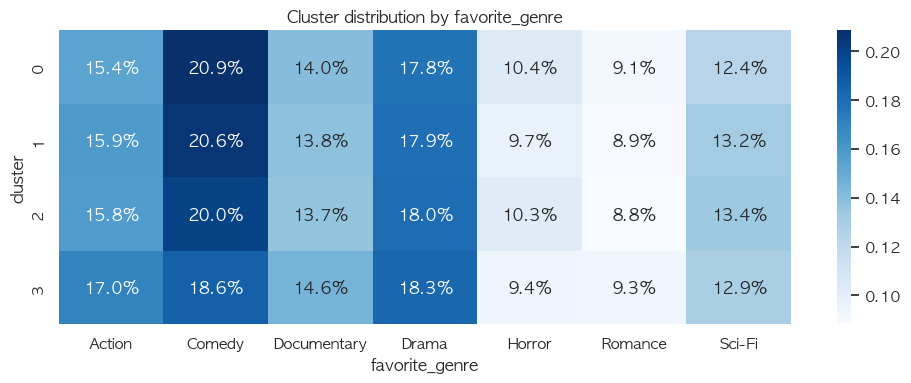

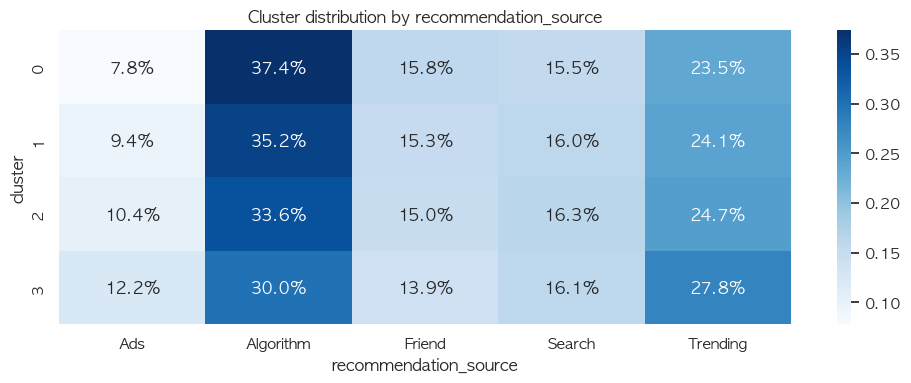

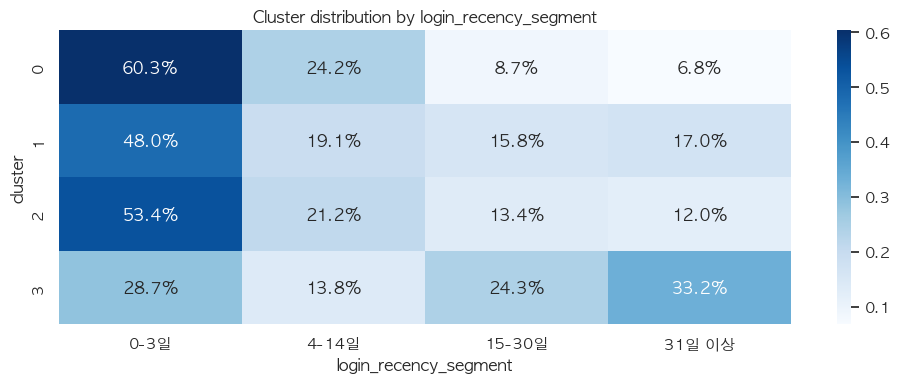

In [15]:
for col in ['subscription_type', 'primary_device', 'favorite_genre', 'recommendation_source', 'login_recency_segment']:
    dist = pd.crosstab(analysis_df['cluster'], analysis_df[col], normalize='index')
    plt.figure(figsize=(10, 4))
    sns.heatmap(dist, annot=True, fmt='.1%', cmap='Blues')
    plt.title(f'Cluster distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('cluster')
    plt.tight_layout()
    plt.show()

## 실제 군집 해석 (`SELECTED_K = 4` 기준)

### Cluster 3: 고위험 이탈 후보군

- 전체 고객의 약 22.4%이지만 전체 이탈자의 약 51.1%를 차지한다.
- 이탈률은 약 47.9%로 전체 평균 21.0% 대비 약 2.28배 높다.
- 평균 마지막 로그인 공백은 약 20.9일로 가장 길고, 평균 주당 시청 시간은 약 125분으로 가장 낮다.
- 대표 특성은 `Basic`, `Mobile`, 낮은 시청시간, 보통 수준의 완료율, 긴 로그인 공백이다.
- 리텐션 캠페인, 복귀 쿠폰, Basic Plus/Mobile Plus 같은 방어형 요금제 실험의 1순위 대상이다.

### Cluster 1: Basic 중심 중위험군

- 전체 고객의 약 22.2%, 전체 이탈자의 약 28.1%를 차지한다.
- 이탈률은 약 26.6%로 전체 평균보다 높고, lift는 약 1.26이다.
- 이 군집은 `Basic` 고객 비중이 100%로, 요금제 자체의 가격 민감도 또는 낮은 서비스 경험이 이탈과 연결될 가능성이 크다.
- 다만 Cluster 3보다 시청 시간과 로그인 공백이 양호하므로, 즉시 이탈 직전 고객이라기보다는 업그레이드/혜택 설계 대상에 가깝다.

### Cluster 2: 평균 이하 저위험 일반군

- 전체 고객의 약 33.0%로 가장 큰 군집이다.
- 이탈률은 약 11.3%, lift는 약 0.54로 전체 평균보다 낮다.
- `Standard` 비중이 높고, 시청 시간과 완료율도 중간 이상이다.
- 대규모 일반 유지 고객군으로 볼 수 있으며, 강한 할인보다는 추천 품질 유지와 사용 경험 개선 중심의 관리가 적절하다.

### Cluster 0: 안정적 핵심 유지군

- 전체 고객의 약 22.4%이지만 전체 이탈자의 약 3.0%만 차지한다.
- 이탈률은 약 2.8%, lift는 약 0.13으로 가장 안정적이다.
- 평균 주당 시청 시간은 약 507분, 평균 완료율은 약 81.4%, 추천 클릭률은 약 47.0%로 활동성과 만족도가 가장 높다.
- `Premium`과 `Smart TV` 비중이 높아 고가치 충성 고객군으로 해석할 수 있다.
- 이 군집은 이탈 방어보다 VIP 유지, 프리미엄 콘텐츠 추천, 장기 구독 혜택 설계에 적합하다.

### 전체 결론

- 범주화 기반 KMeans는 고객을 `고위험 이탈군`, `Basic 중심 중위험군`, `일반 유지군`, `핵심 충성군`으로 나누는 데 유용하다.
- 특히 Cluster 3은 고객 수와 이탈자 수가 모두 커서 실무적으로 가장 먼저 대응해야 하는 군집이다.
- Cluster 1은 Basic 고객 전체를 별도로 분리해주므로, 신규 중간 요금제나 업그레이드 실험의 핵심 타겟으로 볼 수 있다.
- Cluster 0은 이탈 가능성이 낮은 우량 고객군이므로, 할인보다 만족도 유지와 프리미엄 경험 강화가 더 적합하다.

## 해석 가이드

- `churn_rate`와 `lift`가 높은 군집은 리텐션 우선순위가 높다.
- `users`가 너무 작은 군집은 우연성이 커서 별도 검증이 필요하다.
- `cluster_profile`에서 각 군집의 대표 요금제, 기기, 장르, 추천 경로를 확인한다.
- 팀원의 scaling+clip 방식 결과와 비교할 때는 `cluster_summary`, `cluster_profile` 형태를 맞춰 비교한다.